In [1]:
from netCDF4 import Dataset as NetCDFFile 
import matplotlib.pyplot as plt
import numpy as np
import geopandas
import rasterio
from mpl_toolkits.basemap import Basemap

import rioxarray
import xarray
import fiona
from fiona import transform
from rasterio.plot import show

import glob, os

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.patches as patches


from PIL import Image
import matplotlib

In [2]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]



In [3]:
# I think I might actually only use the best 2 of these
# OC3 and RBD were best!

# s2a: [443., 492., 560., 665., 704., 740., 783., 833., 865.])
# s2b: [442., 492., 559., 665., 704., 739., 780., 833., 864.]

def OC2_tuned_SD(df):
    return chla_OC2(df, 
                    a=0.66076503, b=5.08547344, c=94.24865753,
                    d=392.15536774, e=506.06892637)

def OC2_tuned_S2(df, sensor='S2A'):
    if sensor == 'S2A':
        Rrs_444 = 'Rrs_443'
        Rrs_566 = 'Rrs_560'
    if sensor == 'S2B':
        Rrs_444 = 'Rrs_442'
        Rrs_566 = 'Rrs_559'
    return chla_OC2(df, Rrs_444=Rrs_444, Rrs_492='Rrs_492',
                    Rrs_566=Rrs_566,
                    e=-236.21822107, d=-223.27846193, 
                    c=-60.43881125, b=-5.14908542, a=0.85427622)

def OC3_tuned_SD(df):
    return chla_OC3(df,
                    e=-46.25366116, d=-12.96638103, c=7.29677618,
                    b=-0.97394641, a=0.65452869)

def OC3_tuned_S2(df, sensor='S2A'):
    if sensor == 'S2A':
        Rrs_444 = 'Rrs_443'
        Rrs_566 = 'Rrs_560'
    if sensor == 'S2B':
        Rrs_444 = 'Rrs_442'
        Rrs_566 = 'Rrs_559'
    return chla_OC3(df, Rrs_444=Rrs_444, Rrs_492='Rrs_492',
                    Rrs_566=Rrs_566,
                    e=-46.52945764, d=-23.12084579, c=3.57432539,
                    b=0.61589994, a=0.83770047)

def OC4_tuned_SD(df):
    return chla_OC4(df,
                    e=-1.14494220e+03, d=1.42784407e+02,
                    c=4.78583476e+01, b=-4.49757978e+00,
                    a=6.59589727e-01)

def RBD_tuned_SD(df):
    rbd=chla_RBD(df)
    return np.polyval([4.63636160e+03, -1.71869443e+00],
                      rbd)
def RBD_tuned_S2(df, Rrs_708='Rrs_704', Rrs_666='Rrs_665'):
    rbd=chla_RBD(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return np.polyval([4.71412516e+03, 1.59045623e+00],
                      rbd)

In [4]:
# these are the coefficients I've found from S2_SD_nice fitting exercise
# note that coeffs in order from highest degree to lowest of the polynomial
# this is the way np.polyfit works

# OC2_X
# SD_coeff: 
# [506.06892637 392.15536774  94.24865753   5.08547344   0.66076503]
# S2_coeff:
# [-236.21822107 -223.27846193  -60.43881125   -5.14908542    0.85427622]
# OC3_X
# SD_coeff: 
# [-46.25366116 -12.96638103   7.29677618  -0.97394641   0.65452869]
# S2_coeff:
# [-46.52945764 -23.12084579   3.57432539   0.61589994   0.83770047]
# OC4_X
# SD_coeff:
# [-1.14494220e+03  1.42784407e+02  4.78583476e+01 -4.49757978e+00
#   6.59589727e-01]

# NIR
# SD_coeff:
# [-2.30073398 25.10614164]
# S2_coeff:
# [-14.93664794  49.26958544]
# NDCI
# SD_coeff:
# [ 0.26646029 21.06133001]
# S2_coeff:
# [-54.6739819   37.10374135]
# RBD
# SD_coeff:
# [ 4.63636160e+03 -1.71869443e+00]
# S2_coeff:
# [4.71412516e+03 1.59045623e+00]
# RBR3
# SD_coeff:
# [-7.79286034 31.40022337]
# S2_coeff:
# [-8.62183986 35.73590117]

In [5]:
with fiona.open("map_stuff/Download_airthrey_water_2483224/vml_5464100/ns/vml-ns89nw_Water_Area.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]
shapes = [shapes[10], shapes[28]] # indices of lhs and rhs of loch

In [6]:
# run the routine for all planet files
planet_L2W = []
for i, file in enumerate(glob.glob("planetData/acolite_output_L2W/*L2W.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly

    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_666'].copy()
    a.data = OC3_tuned_SD(xds)
    xds['chla_OC3_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

    a = xds['Rrs_666'].copy()
    a.data = RBD_tuned_SD(xds)
    xds['chla_RBD_tuned_SD'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/planet/' + file[30:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 planetData/acolite_output_L2W/PlanetScope_2445_2023_01_30_10_14_27_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
1 planetData/acolite_output_L2W/PlanetScope_2495_2023_03_09_10_59_42_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
2 planetData/acolite_output_L2W/PlanetScope_242b_2023_05_29_10_21_47_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
3 planetData/acolite_output_L2W/PlanetScope_24c4_2024_02_03_10_34_26_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': 

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
31 planetData/acolite_output_L2W/PlanetScope_24c4_2023_04_07_10_29_29_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
32 planetData/acolite_output_L2W/PlanetScope_242b_2022_02_19_10_26_11_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
33 planetData/acolite_output_L2W/PlanetScope_248c_2023_04_21_11_01_33_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
61 planetData/acolite_output_L2W/PlanetScope_2470_2023_06_09_11_08_06_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
62 planetData/acolite_output_L2W/PlanetScope_2407_2022_04_24_11_16_56_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
63 planetData/acolite_output_L2W/PlanetScope_242b_2022_03_21_10_27_40_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
91 planetData/acolite_output_L2W/PlanetScope_2458_2024_02_01_10_41_51_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
92 planetData/acolite_output_L2W/PlanetScope_2480_2023_01_28_11_04_45_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
93 planetData/acolite_output_L2W/PlanetScope_2416_2022_02_11_11_20_04_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0,

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
121 planetData/acolite_output_L2W/PlanetScope_2415_2023_09_12_10_32_01_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
122 planetData/acolite_output_L2W/PlanetScope_247a_2023_11_07_11_12_35_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
123 planetData/acolite_output_L2W/PlanetScope_24bc_2024_02_26_10_39_11_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

...

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
211 planetData/acolite_output_L2W/PlanetScope_2451_2023_09_01_10_25_03_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
212 planetData/acolite_output_L2W/PlanetScope_2451_2023_06_13_10_25_33_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
213 planetData/acolite_output_L2W/PlanetScope_242a_2021_05_30_10_38_36_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
244 planetData/acolite_output_L2W/PlanetScope_2275_2020_04_07_10_35_46_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
245 planetData/acolite_output_L2W/PlanetScope_2441_2021_01_25_10_46_35_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
246 planetData/acolite_output_L2W/PlanetScope_24f5_2024_01_06_11_35_30_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
275 planetData/acolite_output_L2W/PlanetScope_2412_2021_04_03_11_27_30_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
276 planetData/acolite_output_L2W/PlanetScope_2424_2021_02_08_11_28_13_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
277 planetData/acolite_output_L2W/PlanetScope_2439_2023_10_30_10_36_21_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
305 planetData/acolite_output_L2W/PlanetScope_2402_2022_07_04_11_16_57_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
306 planetData/acolite_output_L2W/PlanetScope_247f_2023_09_07_11_11_44_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
307 planetData/acolite_output_L2W/PlanetScope_2458_2021_11_15_10_36_42_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
335 planetData/acolite_output_L2W/PlanetScope_2235_2020_11_19_10_33_52_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}
336 planetData/acolite_output_L2W/PlanetScope_2448_2022_09_14_10_23_16_L2W.nc
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 298, 'height': 204, 'count': 21, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 442473.0,
       0.0, -3.0, 6223080.0)}


In [7]:
for i, file in enumerate(glob.glob("S2_downloads/acolite_output/*L2W.nc")):
    print(i, file)

0 S2_downloads/acolite_output/S2A_MSI_2023_10_07_11_45_36_T30VVH_L2W.nc
1 S2_downloads/acolite_output/S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.nc
2 S2_downloads/acolite_output/S2B_MSI_2023_04_22_11_35_41_T30VVH_L2W.nc
3 S2_downloads/acolite_output/S2B_MSI_2023_09_02_11_45_40_T30VVH_L2W.nc
4 S2_downloads/acolite_output/S2B_MSI_2022_10_07_11_45_33_T30VVH_L2W.nc
5 S2_downloads/acolite_output/S2A_MSI_2022_04_22_11_35_44_T30VVH_L2W.nc
6 S2_downloads/acolite_output/S2A_MSI_2023_07_16_11_35_44_T30VVH_L2W.nc
7 S2_downloads/acolite_output/S2B_MSI_2023_10_12_11_45_37_T30VVH_L2W.nc
8 S2_downloads/acolite_output/S2A_MSI_2022_07_04_11_45_49_T30VVH_L2W.nc
9 S2_downloads/acolite_output/S2A_MSI_2023_03_08_11_35_34_T30VVH_L2W.nc
10 S2_downloads/acolite_output/S2B_MSI_2023_09_29_11_35_41_T30VVH_L2W.nc
11 S2_downloads/acolite_output/S2A_MSI_2023_09_24_11_35_41_T30VVH_L2W.nc
12 S2_downloads/acolite_output/S2B_MSI_2023_07_11_11_35_44_T30VVH_L2W.nc
13 S2_downloads/acolite_output/S2B_MSI_2023_04_15_11_45_36_T3

In [8]:
file[28:-3]

'S2B_MSI_2022_03_28_11_35_36_T30VVH_L2W'

In [9]:
# run the routine for all Sentinel-2 files
planet_L2W = []
for i, file in enumerate(glob.glob("S2_downloads/acolite_output/*L2W.nc")):
    print(i, file)
    planet_L2W.append(file)
    xds = xarray.open_dataset(file)
    xds.rio.write_crs("epsg:32630", inplace=True)
    # do some chl-a calcs
    # can obviously do any math operation I want
    # can probably use my existing algorithm code if the bands are named similarly
    sensor = file[28:31] # this gets the S2A or S2B section of the filename
    print('sensor: ' + sensor)
    # this is a hacky way of ensuring the thing we put into xds is the right format
    a = xds['Rrs_665'].copy()
    a.data = OC3_tuned_S2(xds, sensor=sensor)
    xds['chla_OC3_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_OC3_tuned_S2'].attrs['parameter'] = 'chla_OC3_tuned_S2'

    a = xds['Rrs_665'].copy()
    a.data = RBD_tuned_S2(xds)
    xds['chla_RBD_tuned_S2'] = a
    # make sure it is named properly
    xds['chla_RBD_tuned_S2'].attrs['parameter'] = 'chla_RBD_tuned_S2'

    # IMPORTANT
    # change long variable names as these are used when we convert to raster as band names
    for var in list(xds.data_vars):
        try:
            xds[var].attrs['long_name'] = xds[var].attrs['parameter']
        except KeyError:
            pass

    xds.rio.to_raster('map_stuff/rasters/Sentinel2/temp.tif')
    # open raster and mask

    with rasterio.open('map_stuff/rasters/Sentinel2/temp.tif') as src:
        out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                      nodata=np.nan, all_touched=False)
        out_meta = src.meta
        print(src.meta)
        out_desc = src.descriptions
        
    # write masked raster data to a new raster file
    fname = 'map_stuff/rasters/Sentinel2/' + file[28:-3] + '.tif'

    out_meta.update({"driver": "GTiff",
                     "transform": out_transform})

    with rasterio.open(fname, "w", **out_meta) as dest:
        dest.write(out_image)
        dest.descriptions = out_desc

0 S2_downloads/acolite_output/S2A_MSI_2023_10_07_11_45_36_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
1 S2_downloads/acolite_output/S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
2 S2_downloads/acolite_output/S2B_MSI_2023_04_22_11_35_41_T30VVH_L2W.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
3 S2_downloads/acolite_output/S2B_MSI_2023_09_02_11_45_40_T30VVH_L2W.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 

sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
32 S2_downloads/acolite_output/S2A_MSI_2023_09_04_11_35_44_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
33 S2_downloads/acolite_output/S2B_MSI_2023_03_23_11_35_41_T30VVH_L2W.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
34 S2_downloads/acolite_output/S2A_MSI_2022_09_19_11_35_47_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': 

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
63 S2_downloads/acolite_output/S2A_MSI_2022_06_04_11_45_43_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
64 S2_downloads/acolite_output/S2A_MSI_2023_10_17_11_45_35_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
65 S2_downloads/acolite_output/S2A_MSI_2022_09_12_11_45_46_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0,

sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
93 S2_downloads/acolite_output/S2B_MSI_2023_07_31_11_35_44_T30VVH_L2W.nc
sensor: S2B
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
94 S2_downloads/acolite_output/S2A_MSI_2023_08_28_11_45_41_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': Affine(10.0, 0.0, 442450.0,
       0.0, -10.0, 6223100.0)}
95 S2_downloads/acolite_output/S2A_MSI_2023_05_07_11_35_39_T30VVH_L2W.nc
sensor: S2A
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 101, 'height': 71, 'count': 28, 'crs': CRS.from_epsg(32630), 'transform': 

In [10]:
xds

<xarray.Dataset> Size: 833kB
Dimensions:              (x: 101, y: 71)
Coordinates:
    transverse_mercator  int64 8B 0
  * x                    (x) float64 808B 4.425e+05 4.425e+05 ... 4.435e+05
  * y                    (y) float64 568B 6.223e+06 6.223e+06 ... 6.222e+06
Data variables: (12/28)
    lon                  (y, x) float32 29kB -3.926 -3.926 ... -3.91 -3.91
    lat                  (y, x) float32 29kB 56.15 56.15 56.15 ... 56.14 56.14
    rhow_442             (y, x) float32 29kB 0.03338 0.03338 ... 0.03395 0.03395
    Rrs_442              (y, x) float32 29kB 0.01062 0.01062 ... 0.01081 0.01081
    rhow_492             (y, x) float32 29kB 0.0324 0.03169 ... 0.04718 0.05541
    Rrs_492              (y, x) float32 29kB 0.01031 0.01009 ... 0.01502 0.01764
    ...                   ...
    rhow_2186            (y, x) float32 29kB 0.0633 0.08221 ... 0.1654 0.1654
    Rrs_2186             (y, x) float32 29kB 0.02015 0.02617 ... 0.05264 0.05264
    l2_flags             (y, x) int32 29kB 0 0 0 0 0 0 0 0 0 ... 4 0 0 0 0 0 0 0
    chl_oc3              (y, x) float32 29kB 3.245 3.708 2.485 ... 6.171 4.423
    chla_OC3_tuned_S2    (y, x) float64 57kB 6.581 6.653 6.689 ... 7.805 6.886
    chla_RBD_tuned_S2    (y, x) float32 29kB 18.15 23.64 22.49 ... 48.85 42.27
Attributes: (12/403)
    generated_by:                              ACOLITE
    generated_on:                              2024-03-07 14:24:18 GMT
    contact:                                   Quinten Vanhellemont
    product_type:                              NetCDF
    metadata_profile:                          beam
    metadata_version:                          0.5
    ...                                        ...
    ac_bands:                                  1,2,3,4,5,6,7,8,8A
    ac_nbands_fit:                             2
    ac_band1_idx:                              1
    ac_band1:                                  2
    ac_band2_idx:                              3
    ac_band2:                                  4

In [11]:
np.nanmin(xds['chla_OC3_tuned_S2'])

0.0033101178404215037

In [12]:
xds = xarray.open_dataset(planet_L2W[0])

In [13]:
xds.rio.write_crs("epsg:32630", inplace=True)

<xarray.Dataset> Size: 747kB
Dimensions:              (x: 101, y: 71)
Coordinates:
    transverse_mercator  int64 8B 0
  * x                    (x) float64 808B 4.425e+05 4.425e+05 ... 4.435e+05
  * y                    (y) float64 568B 6.223e+06 6.223e+06 ... 6.222e+06
Data variables: (12/26)
    lon                  (y, x) float32 29kB ...
    lat                  (y, x) float32 29kB ...
    rhow_443             (y, x) float32 29kB ...
    Rrs_443              (y, x) float32 29kB ...
    rhow_492             (y, x) float32 29kB ...
    Rrs_492              (y, x) float32 29kB ...
    ...                   ...
    rhow_1614            (y, x) float32 29kB ...
    Rrs_1614             (y, x) float32 29kB ...
    rhow_2202            (y, x) float32 29kB ...
    Rrs_2202             (y, x) float32 29kB ...
    l2_flags             (y, x) int32 29kB ...
    chl_oc3              (y, x) float32 29kB ...
Attributes: (12/403)
    generated_by:                              ACOLITE
    generated_on:                              2024-03-07 14:17:57 GMT
    contact:                                   Quinten Vanhellemont
    product_type:                              NetCDF
    metadata_profile:                          beam
    metadata_version:                          0.5
    ...                                        ...
    ac_bands:                                  1,2,3,4,5,6,7,8,8A
    ac_nbands_fit:                             2
    ac_band1_idx:                              0
    ac_band1:                                  1
    ac_band2_idx:                              1
    ac_band2:                                  2

In [14]:
# do some chl-a calcs
# can obviously do any math operation I want
# can probably use my existing algorithm code if the bands are named similarly

# this is a hacky way of ensuring the thing we put into xds is the right format
a = xds['Rrs_666'].copy()
a.data = OC3_tuned_SD(xds)
xds['chla_OC3_tuned_SD'] = a
# make sure it is named properly
xds['chla_OC3_tuned_SD'].attrs['parameter'] = 'chla_OC3_tuned_SD'

a = xds['Rrs_666'].copy()
a.data = RBD_tuned_SD(xds)
xds['chla_RBD_tuned_SD'] = a
# make sure it is named properly
xds['chla_RBD_tuned_SD'].attrs['parameter'] = 'chla_RBD_tuned_SD'

# IMPORTANT
# change long variable names as these are used when we convert to raster as band names
for var in list(xds.data_vars):
    try:
        xds[var].attrs['long_name'] = xds[var].attrs['parameter']
    except KeyError:
        pass

xds.rio.to_raster('map_stuff/rasters/planet/temp.tif')

KeyError: "No variable named 'Rrs_666'. Variables on the dataset include ['transverse_mercator', 'x', 'y', 'lon', 'lat', ..., 'Rrs_1614', 'rhow_2202', 'Rrs_2202', 'l2_flags', 'chl_oc3']"

In [ ]:
with fiona.open("map_stuff/Download_airthrey_water_2483224/vml_5464100/ns/vml-ns89nw_Water_Area.shp",
                "r") as shapefile:
    
    shapes = [transform.transform_geom('EPSG:27700', 'EPSG:32630',
                                       feature["geometry"]) for feature in shapefile]

In [ ]:
shapes = [shapes[10], shapes[28]] # indices of lhs and rhs of loch

# open raster and mask

with rasterio.open('map_stuff/rasters/planet/temp.tif') as src:
    out_image, out_transform = rasterio.mask.mask(src, shapes, crop=False,
                                                  nodata=np.nan, all_touched=False)
    out_meta = src.meta
    print(src.meta)
    out_desc = src.descriptions

In [ ]:
# write masked raster data to a new raster file
fname = 'map_stuff/rasters/planet/' + planet_L2W[0][30:-3] + '.tif'

out_meta.update({"driver": "GTiff",
                 "transform": out_transform})

with rasterio.open(fname, "w", **out_meta) as dest:
    dest.write(out_image)
    dest.descriptions = out_desc

In [ ]:
fig, ax = plt.subplots()

with rasterio.open('map_stuff/aerial.tif') as src:
    print(np.nanmin(src.read(1)))
    print(src.read(1).shape)
    print(src.read(2).shape)
    print(src.read(3).shape)
#     plt.imshow(src.read(26),
#               cmap='winter', vmin=0, vmax=50, 
#                extent=[lon_min, lon_max,
#                       lat_min, lat_max]
#               )
    show(src.read(), transform=src.transform,ax=ax)
    
with rasterio.open('map_stuff/aerial2.tif') as src:
    print(np.nanmin(src.read(1)))
    print(src.read(1).shape)
    print(src.read(2).shape)
    print(src.read(3).shape)
#     plt.imshow(src.read(26),
#               cmap='winter', vmin=0, vmax=50, 
#                extent=[lon_min, lon_max,
#                       lat_min, lat_max]
#               )
    show(src.read(), transform=src.transform, ax=ax)
    
    
ax.set_xlim(280500, 281250)
ax.set_ylim(696300, 696800)

In [19]:
def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

# Open the image from my computer
northArrow = open_image_local('map_stuff/north_arrow2.png')

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_68533/293226706.py:78: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_68533/293226706.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


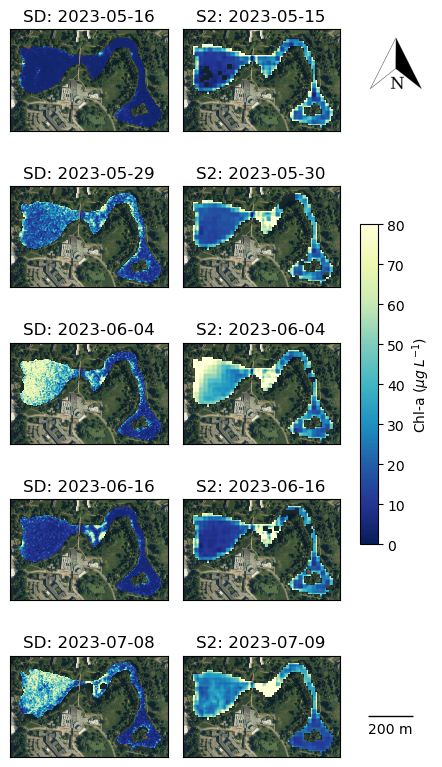

In [158]:
# note: we are working in EPSG:32630, where units are metres

fig, axs = plt.subplots(5, 2, figsize=(4.5,8))

s2_images = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
             'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
             'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
             'S2A_MSI_2023_06_16_11_35_43_T30VVH_L2W.tif',
             'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif',
             'S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.tif']

planet_images = ['PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif',
                 'PlanetScope_242b_2023_05_29_10_21_47_L2W.tif',
                 'PlanetScope_2440_2023_06_04_10_26_56_L2W.tif',
                 'PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif',
                 'PlanetScope_242d_2023_07_08_10_29_51_L2W.tif',
                 'PlanetScope_24b3_2023_07_21_10_34_37_L2W.tif']

axs = axs.reshape((5, 2))


for i, sensor, band in zip([0, 1], ['planet/', 'Sentinel2/'], [20, 28]):
    for ax, image in zip(axs[:, i], [planet_images[:-1], s2_images[:-1]][i]):
        
        if sensor == 'planet/':
            title = 'SD: ' + image[17:21] + '-' + image[22:24] + '-' + image[25:27]
        else:
            title = 'S2: ' + image[8:12] + '-' + image[13:15] + '-' + image[16:18]
            
        ax.set_title(title)

        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(band), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=80)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            show(src.read(band), transform=src.transform, cmap='YlGnBu_r',
                 vmin=0, vmax=80, ax=ax)

        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are off

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

        


# fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

scale_ax = fig.add_axes([0.81, 0.05, 0.04, 0.1]) # (left, bottom, width, height)
scale_ax.axis('off')
# scale_ax.add_artist(scalebar)

arrow_ax = fig.add_axes([0.81, 0.8, 0.16, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scale_ax.add_artist(scalebar)

# arrow_ax.arrow(0.04, 0.04, 0, 0.0002, color='k',
#                width=0.0005, head_length=0.00003, 
#                length_includes_head=True, alpha=0.1)

# arrow_ax.annotate("N", xy=(1.02, 0.6), xytext=(1.02, 0.8),
#              arrowprops=dict(arrowstyle="<-", lw=1,),
#                   horizontalalignment="center",
                  
#                  )


# arrow_ax.text(1.7, 0.7, "  ",
#             ha="center", va="center", rotation=90, size=12,
#             bbox=dict(boxstyle="rarrow,pad=0.3",
#                       fc='white', ec="k", lw=1))


# t = arrow_ax.text(1.7, 0.7, "N", 
#             ha="center", va="center", rotation=0, size=12,
#               backgroundcolor=None,
# )

# t.set_bbox(dict(alpha=0.))

arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.savefig('figures_for_paper/map_test.pdf', dpi=300)
plt.savefig('figures_for_paper/chla_maps.svg', dpi=300)


plt.show()

<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1146874480.py:78: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1146874480.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


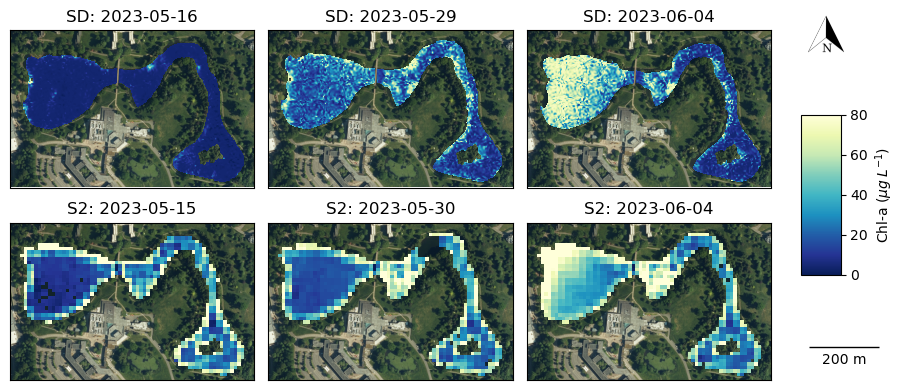

In [21]:
# note: we are working in EPSG:32630, where units are metres

fig, axs = plt.subplots(2, 3, figsize=(10, 4))

s2_images = ['S2B_MSI_2023_05_15_11_45_39_T30VVH_L2W.tif',
             'S2A_MSI_2023_05_30_11_45_39_T30VVH_L2W.tif',
             'S2B_MSI_2023_06_04_11_45_40_T30VVH_L2W.tif',
             'S2A_MSI_2023_06_16_11_35_43_T30VVH_L2W.tif',
             'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif',
             'S2A_MSI_2023_07_19_11_45_40_T30VVH_L2W.tif']

planet_images = ['PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif',
                 'PlanetScope_242b_2023_05_29_10_21_47_L2W.tif',
                 'PlanetScope_2440_2023_06_04_10_26_56_L2W.tif',
                 'PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif',
                 'PlanetScope_242d_2023_07_08_10_29_51_L2W.tif',
                 'PlanetScope_24b3_2023_07_21_10_34_37_L2W.tif']

# axs = axs.reshape((5, 2))


for i, sensor, band in zip([0, 1], ['planet/', 'Sentinel2/'], [20, 28]):
    for ax, image in zip(axs[i, :], [planet_images[:-3], s2_images[:-3]][i]):
        
        if sensor == 'planet/':
            title = 'SD: ' + image[17:21] + '-' + image[22:24] + '-' + image[25:27]
        else:
            title = 'S2: ' + image[8:12] + '-' + image[13:15] + '-' + image[16:18]
            
        ax.set_title(title)

        with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            # use imshow so that we have something to map the colorbar to
            c = ax.imshow(src.read(band), 
                                     cmap='YlGnBu_r', 
                                     vmin=0, 
                                     vmax=80)

        with rasterio.open('map_stuff/rasters/' + sensor + image) as src:
            show(src.read(band), transform=src.transform, cmap='YlGnBu_r',
                 vmin=0, vmax=80, ax=ax)

        ax.set_xlim(442550, 443250)
        ax.set_ylim(6222550, 6223000)
        
        
        ax.tick_params(axis='x',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       bottom=False,      # ticks along the bottom edge are off
                       top=False,         # ticks along the top edge are off
                       labelbottom=False) # labels along the bottom edge are off

        ax.tick_params(axis='y',          # changes apply to the x-axis
                       which='both',      # both major and minor ticks are affected
                       left=False,      # ticks along the bottom edge are off
                       right=False,         # ticks along the top edge are off
                       labelleft=False) # labels along the bottom edge are off
        
        scalebar = AnchoredSizeBar(ax.transData,
                                   200, '200 m', 'lower left', 
                                   pad=0.5,
                                   sep=4,
                                   color='black',
                                   frameon=False,
                                   size_vertical=1,
                                   #fontproperties=fontprops
                                  )

        


# fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')

scale_ax = fig.add_axes([0.81, 0.05, 0.04, 0.1]) # (left, bottom, width, height)
scale_ax.axis('off')
# scale_ax.add_artist(scalebar)

arrow_ax = fig.add_axes([0.81, 0.8, 0.05, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scale_ax.add_artist(scalebar)

# arrow_ax.arrow(0.04, 0.04, 0, 0.0002, color='k',
#                width=0.0005, head_length=0.00003, 
#                length_includes_head=True, alpha=0.1)

# arrow_ax.annotate("N", xy=(1.02, 0.6), xytext=(1.02, 0.8),
#              arrowprops=dict(arrowstyle="<-", lw=1,),
#                   horizontalalignment="center",
                  
#                  )


# arrow_ax.text(1.7, 0.7, "  ",
#             ha="center", va="center", rotation=90, size=12,
#             bbox=dict(boxstyle="rarrow,pad=0.3",
#                       fc='white', ec="k", lw=1))


# t = arrow_ax.text(1.7, 0.7, "N", 
#             ha="center", va="center", rotation=0, size=12,
#               backgroundcolor=None,
# )

# t.set_bbox(dict(alpha=0.))

arrow_ax.imshow(northArrow,
                cmap=matplotlib.colors.ListedColormap(['black', 'none'])
)

fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.savefig('figs_for_presentation/map_test2_pres.svg', dpi=300)

plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1233483020.py:42: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')
/var/folders/90/q80625gx5215cctg3hvm820r0000gn/T/ipykernel_85291/1233483020.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)


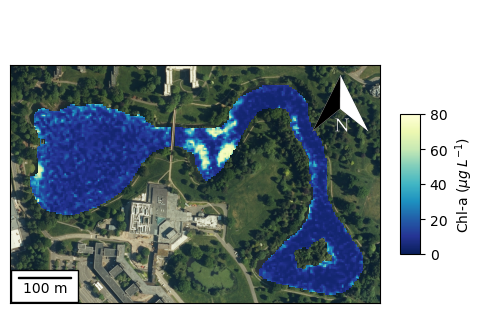

In [30]:
northArrow3 = open_image_local('map_stuff/north_arrow2_invert.png')

# note: we are working in EPSG:32630, where units are metres

fig, ax = plt.subplots(figsize=(5, 3.5))

with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)

with rasterio.open('map_stuff/rasters/planet/PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif') as src:
    # use imshow so that we have something to map the colorbar to
    c = ax.imshow(src.read(20), 
                             cmap='YlGnBu_r', 
                             vmin=0, 
                             vmax=80)

with rasterio.open('map_stuff/rasters/planet/PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif') as src:
    show(src.read(20), transform=src.transform, cmap='YlGnBu_r',
         vmin=0, vmax=80, ax=ax)

ax.set_xlim(442550, 443250)
ax.set_ylim(6222550, 6223000)


ax.tick_params(axis='x',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               bottom=False,      # ticks along the bottom edge are off
               top=False,         # ticks along the top edge are off
               labelbottom=False) # labels along the bottom edge are off

ax.tick_params(axis='y',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               left=False,      # ticks along the bottom edge are off
               right=False,         # ticks along the top edge are off
               labelleft=False) # labels along the bottom edge are off



# fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.81, 0.3, 0.04, 0.4]) # (left, bottom, width, height)
fig.colorbar(c, cax=cbar_ax, label='Chl-a ($\mu g \: L^{-1}$)')



arrow_ax = fig.add_axes([0.81, 0.8, 0.05, 0.2]) # (left, bottom, width, height)
arrow_ax.axis('off')

scalebar = AnchoredSizeBar(ax.transData,
                           100, '100 m', 'lower left', 
                           pad=0.5,
                           sep=2,
                           color='black',
                           frameon=True,
                           size_vertical=1,
                           #fontproperties=fontprops
                          )

ax.add_artist(scalebar)


ax.imshow(northArrow3,
          cmap='Greys_r',
#                 cmap=matplotlib.colors.ListedColormap(['white', 'white']),
          extent=[443100, 443250, 6222850, 6223000] # (left, right, bottom, top)
            )    

fig.tight_layout(rect=[0.0, 0.0, 0.8, 1]) # rect: tuple (left, bottom, right, top), default: (0, 0, 1, 1)
plt.savefig('figures_for_paper/floating_heart.svg', dpi=300)

plt.show()

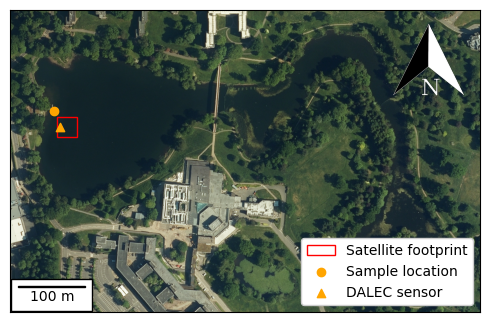

In [63]:
northArrow3 = open_image_local('map_stuff/north_arrow2_invert.png')

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
with rasterio.open('map_stuff/aerial_merged_32630.tif') as src:
            show(src.read(), transform=src.transform,adjust=True, ax=ax)
        
ax.set_xlim(442550, 443250)
ax.set_ylim(6222550, 6223000)

scalebar = AnchoredSizeBar(ax.transData,
                           100, '100 m', 'lower left', 
                           pad=0.5,
                           sep=2,
                           color='black',
                           frameon=True,
                           size_vertical=1,
                           #fontproperties=fontprops
                          )

ax.add_artist(scalebar)

# 442634.8257971745, 6222824.910507713 is the centre of the box 10 m east of the dalec

# for i in range(10):
#     for j in range(10):
#         rect = patches.Rectangle((442634.8257971745-i*3 + 12,
#                                   6222824.910507713- j*3 + 12), 3, 3,
#                                  linewidth=0.5, edgecolor='r', facecolor='none')

#         # Add the patch to the Axes
#         ax.add_patch(rect)
        
# for i in range(3):
#     for j in range(3):
#         rect = patches.Rectangle((442634.8257971745-i*10 + 5,
#                                   6222824.910507713- j*10 + 5), 10, 10,
#                                  linewidth=0.5, edgecolor='green', facecolor='none')

#         # Add the patch to the Axes
#         ax.add_patch(rect)
        
rect = patches.Rectangle((442634.8257971745 - 15,
                          6222824.910507713 - 15), 30, 30,
                         linewidth=1, edgecolor='r', facecolor='none',
                         label='Satellite footprint')

# Add the patch to the Axes
ax.add_patch(rect)

ax.scatter([442634.8257971745-20], [6222824.910507713+25],
           marker='o', color='orange', label='Sample location')

ax.scatter([442634.8257971745-10], [6222824.910507713],
           marker='^', color='orange', label='DALEC sensor')


        
# rect = patches.Rectangle((442634.8257971745,
#                           6222824.910507713), 15, 15,
#                                  linewidth=0.5, edgecolor='orange', facecolor='none')

# # Add the patch to the Axes
# ax.add_patch(rect)


ax.imshow(northArrow3,
          cmap='Greys_r',
#                 cmap=matplotlib.colors.ListedColormap(['white', 'white']),
          extent=[443100, 443250, 6222850, 6223000] # (left, right, bottom, top)
            )    

ax.tick_params(axis='x',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               bottom=False,      # ticks along the bottom edge are off
               top=False,         # ticks along the top edge are off
               labelbottom=False) # labels along the bottom edge are off

ax.tick_params(axis='y',          # changes apply to the x-axis
               which='both',      # both major and minor ticks are affected
               left=False,      # ticks along the bottom edge are off
               right=False,         # ticks along the top edge are off
               labelleft=False) # labels along the bottom edge are off

ax.legend(loc='lower right', framealpha=1)

fig.tight_layout()

plt.savefig('figures_for_paper/basemap.svg', dpi=1000)

        

In [30]:
for i in range(3):
    for j in range(3):
        print(i, j)

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2


In [240]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[17:21]

'2023'

In [243]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[22:24]

'05'

In [244]:
'PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif'[25:27]

'16'

In [250]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[8:12]

'2023'

In [252]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[13:15]

'07'

In [254]:
'S2A_MSI_2023_07_09_11_45_41_T30VVH_L2W.tif'[16:18]

'09'

In [4]:
planet_images[:-2]

['PlanetScope_24b4_2023_05_16_10_30_33_L2W.tif',
 'PlanetScope_242b_2023_05_29_10_21_47_L2W.tif',
 'PlanetScope_2440_2023_06_04_10_26_56_L2W.tif',
 'PlanetScope_24b9_2023_06_16_10_29_24_L2W.tif']

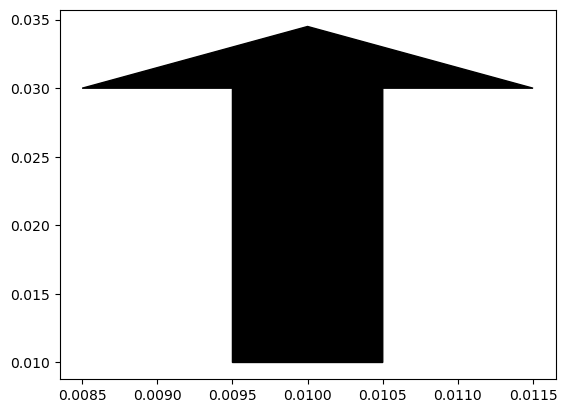

In [11]:
fig, arrow_ax = plt.subplots()
arrow_ax.annotate("N", xy=(0., 0.0), xytext=(0., 0.),
#             arrowprops=dict(arrowstyle="<-")
                 )

arrow_ax.arrow(0.01, 0.01, 0, 0.02, color='k')

AttributeError: AxesImage.set() got an unexpected keyword argument 'scale'

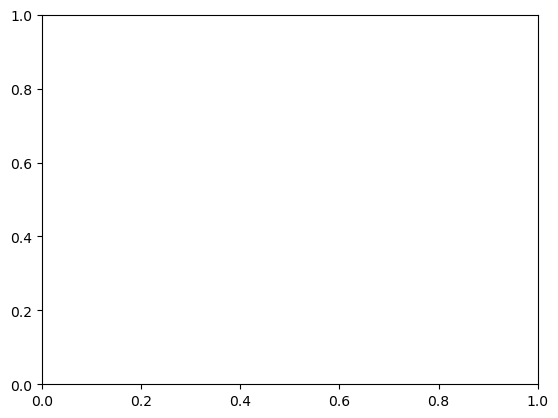